(20, 11)
                Attribute Mercury  Venus  Earth   Moon   Mars Jupiter  Saturn  \
0          Mass (10^24kg)   0.330   4.87   5.97  0.073  0.642    1898     568   
1           Diameter (km)    4879  12104  12756   3475   6792  142984  120536   
2        Density (kg/m^3)    5429   5243   5514   3340   3934    1326     687   
3         Gravity (m/s^2)     3.7    8.9    9.8    1.6    3.7    23.1     9.0   
4  Escape Velocity (km/s)     4.3   10.4   11.2    2.4    5.0    59.5    35.5   

  Uranus Neptune   Pluto  
0   86.8     102  0.0130  
1  51118   49528    2376  
2   1270    1638    1850  
3    8.7    11.0     0.7  
4   21.3    23.5     1.3  
                  Attribute Mercury Venus Earth Moon  Mars  Jupiter   Saturn  \
15     Mean Temperature (C)     167   464    15  -20   -65     -110     -140   
16  Surface Pressure (bars)       0    92     1    0  0.01  Unknown  Unknown   
17          Number of Moons       0     0     1    0     2       95      274   
18             Ring Sy

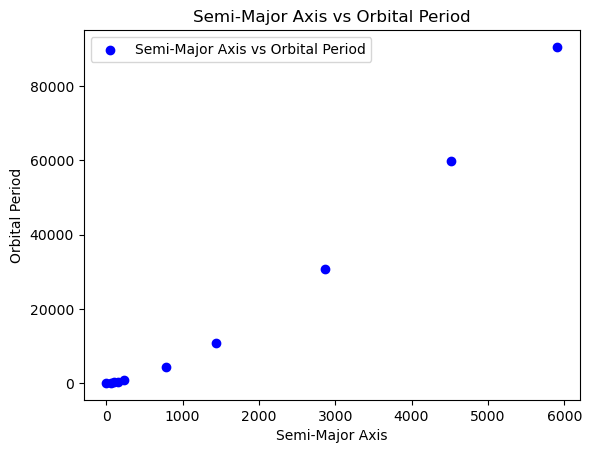

In [41]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit

df = pd.read_csv("solar_system.csv")
print(df.shape)
# 20 rows, 11 columns
print(df.head(5))
print(df.tail(5))
for col in df:
    print(col)
for row in df.itertuples():
    print(row)
orbital_period = df.iloc[10, 1:].astype(float)
perihelion = df.iloc[8, 1:].astype(float)
aphelion = df.iloc[9, 1:].astype(float)
# Perihelion is the closest a orbiting body is to the Sun.
# Aphelion is the farthest a orbiting body is to the Sun.
# Semi-Major Axis is the largest radius size of an eclipse.
semi_major = (perihelion + aphelion)/2
new_row = pd.Series(semi_major, name = 'Semi-Major Axis')
df = pd.concat([df, new_row.to_frame().T])
print(df.shape)
# 21 rows now, 11 columns
plt.scatter(semi_major, orbital_period, color = 'blue', label = 'Semi-Major Axis vs Orbital Period')
plt.xlabel('Semi-Major Axis')
plt.ylabel('Orbital Period')
plt.title('Semi-Major Axis vs Orbital Period')
plt.legend()

0.20
18574.517740227308


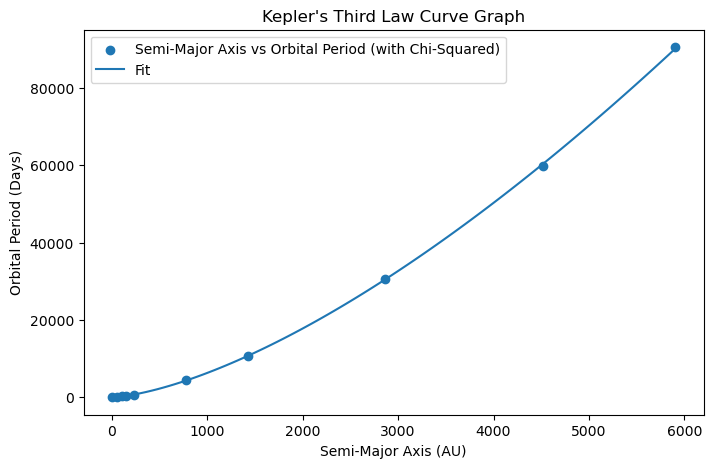

In [54]:
def keplers_third_law(a, m):
    return m * a ** 1.5
popt, pcov = curve_fit(keplers_third_law, semi_major, orbital_period)
m_fit = popt[0]
print(f"{m_fit:.2f}")
residuals = orbital_period - keplers_third_law(semi_major, m_fit)
chi2 = np.sum(residuals**2)
dof = len(df) - 1
chi2_reduced = chi2 / dof
print(chi2_reduced)
plt.figure(figsize = (8,5))
plt.scatter(semi_major, orbital_period, label = "Semi-Major Axis vs Orbital Period (with Chi-Squared)")
new_x = np.linspace(semi_major.min(), semi_major.max(), 100)
plt.plot(new_x, keplers_third_law(new_x, m_fit), label = "Fit")
plt.title("Kepler's Third Law Curve Graph")
plt.xlabel("Semi-Major Axis (AU)")
plt.ylabel("Orbital Period (Days)")
plt.legend()
plt.show()